In [90]:
import pandas as pd
import sqlite3

In [91]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [92]:
pd.read_sql('SELECT * FROM checker LIMIT 2', conn)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1


In [93]:
query = '''
WITH weekday_commits AS (
    SELECT
        DATE(timestamp) AS date,
        strftime('%H' , timestamp) AS hour,
        COUNT(*) AS commits
    FROM
        checker
    WHERE
        uid LIKE 'user_%'
        AND strftime('%w', timestamp) IN ('1', '2', '3', '4', '5')
    GROUP BY
        DATE(timestamp), strftime('%H', timestamp)
),
weekend_commits AS (
    SELECT
        DATE(timestamp) AS date,
        strftime('%H' , timestamp) AS hour,
        COUNT(*) AS commits
    FROM
        checker
    WHERE
        uid LIKE 'user_%'
        AND strftime('%w', timestamp) IN ('6', '7')
    GROUP BY
        DATE(timestamp), strftime('%H', timestamp)
)
SELECT
    'working_day' AS weekday_type,
    hour,
    AVG(commits) AS avg_commits
FROM
    weekday_commits
WHERE
    commits > 0
GROUP BY
    hour
UNION ALL
SELECT
    'weekend' AS weekday_type,
    hour,
    AVG(commits) AS avg_commits
FROM
    weekend_commits
WHERE
    commits > 0
GROUP BY
    hour;
'''

In [94]:
df = pd.read_sql(query, conn)
df

,weekday_type,hour,avg_commits
0,working_day,00,3.000000
1,working_day,03,2.000000
2,working_day,05,7.500000
3,working_day,06,1.500000
4,working_day,07,5.166667
5,working_day,08,3.700000
6,working_day,09,6.000000
7,working_day,10,13.200000
8,working_day,11,6.769231
9,working_day,12,7.181818


In [95]:
commits = df.pivot(index='hour', columns='weekday_type', values='avg_commits').fillna(0)

In [96]:
commits

weekday_type,weekend,working_day
hour,,
00,0.000000,3.000000
03,1.000000,2.000000
05,0.000000,7.500000
06,0.000000,1.500000
07,4.666667,5.166667
08,4.500000,3.700000
09,2.500000,6.000000
10,1.000000,13.200000
11,46.000000,6.769231


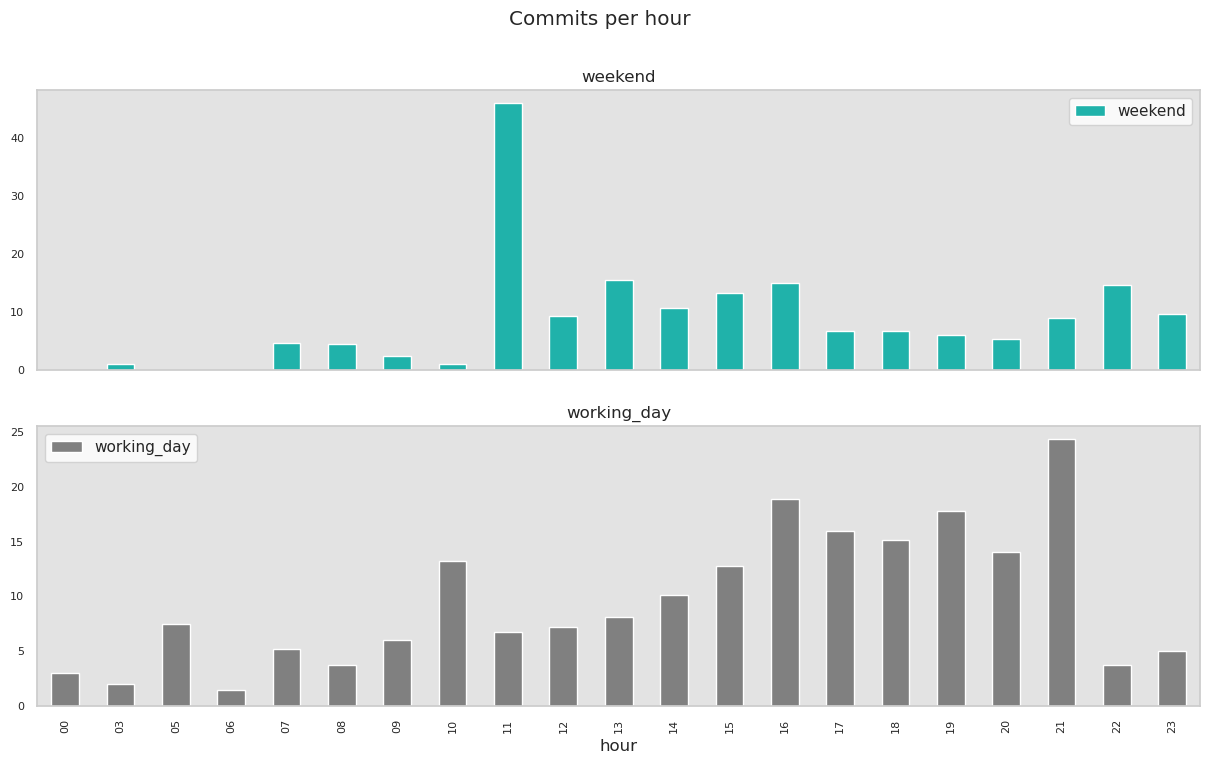

In [97]:
ax = commits.plot(
    kind='bar',
    subplots=True,
    figsize=(15,8),
    fontsize=8,
    color=['lightseagreen', 'grey'],
    title='Commits per hour'
)

ax[0].grid(False)
ax[1].grid(False)

ax[0].set_facecolor('#E3E3E3')
ax[1].set_facecolor('#E3E3E3')


## Is the dynamic different on working days and weekends?

In [98]:
df.set_index('hour', inplace=True)

In [99]:
max_hour_on_weekend = df[df['weekday_type'] == 'weekend']['avg_commits'].idxmax()
max_hour_on_weekend

'11'

In [100]:
max_hour_on_workday = df[df['weekday_type'] == 'working_day']['avg_commits'].idxmax()
max_hour_on_workday

'21'

Answer: YES.

In [101]:
conn.close()